## import thư viện

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import re



In [2]:
train_data = pd.read_csv("Data/train.csv")
test_data = pd.read_csv("Data/test.csv")

train_data

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.1060,0.235,152.429,204947.000000,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.046800,0.1040,0.380,132.921,191956.000000,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.635000,0.2840,0.635,159.953,161037.000000,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.021300,0.3000,0.501,172.472,298093.000000,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.2110,0.619,88.311,254145.000000,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14391,14392,NOISY,I Wish I Was A...,47.0,0.607,0.946,1.0,-2.965,1,0.1500,0.005480,0.000390,0.2780,0.653,120.011,195181.000000,4,10
14392,14393,BLOODSPOT,Deadline Story (feat. Patrick Boos),27.0,0.435,0.951,8.0,-7.475,1,0.0576,0.000005,0.550000,0.0952,0.203,135.034,282043.000000,4,8
14393,14394,Cold Years,Too Far Gone,22.0,0.415,0.941,11.0,-4.300,1,0.0524,0.001810,0.000004,0.3370,0.572,167.978,176529.000000,4,10
14394,14395,The Jaded Hearts Club,Reach Out I'll Be There,37.0,0.493,0.986,1.0,-2.279,1,0.0917,0.000967,0.006620,0.1230,0.567,122.036,186307.000000,4,10


In [5]:
for col in train_data.columns:
    if train_data[col].isnull().sum() > 0:
        print(f"{col} có {train_data[col].isnull().sum()} missing value")

Popularity có 333 missing value
key có 1609 missing value
instrumentalness có 3541 missing value


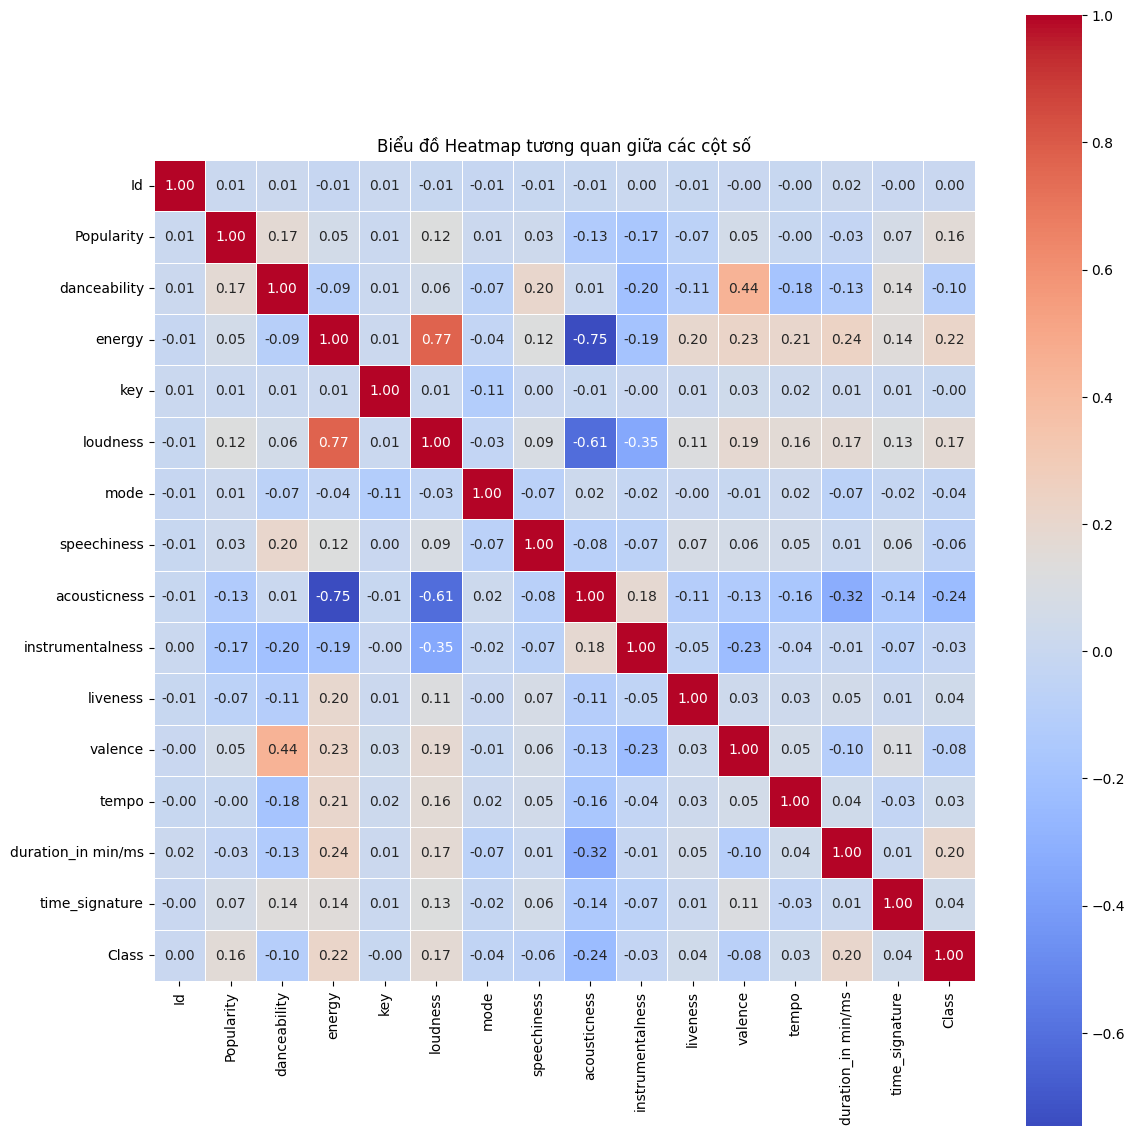

In [3]:
numeric_cols = train_data.select_dtypes(include=['int64', 'float64'])

# Tính ma trận tương quan
corr_matrix = numeric_cols.corr()

# Vẽ biểu đồ heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("Biểu đồ Heatmap tương quan giữa các cột số")
plt.tight_layout()
plt.show()

In [3]:
# train_data['Popularity'].isna().sum()
# test_data['Popularity'].isna().sum()

train_data['Popularity'].fillna(train_data['Popularity'].median(),inplace=True)
test_data['Popularity'].fillna(test_data['Popularity'].median(),inplace=True)

train_data['key'].fillna(train_data['key'].mode()[0], inplace=True)
test_data['key'].fillna(test_data['key'].mode()[0],inplace=True)

train_data['instrumentalness'].fillna(train_data['instrumentalness'].median(),inplace=True)
test_data['instrumentalness'].fillna(test_data['instrumentalness'].median(), inplace= True)

C:\Users\pc\AppData\Local\Temp\ipykernel_10936\2430056120.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['Popularity'].fillna(train_data['Popularity'].median(),inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_10936\2430056120.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [4]:
from sklearn.preprocessing import StandardScaler
# train_data['loudness'] = pd.to_numeric(train_data['loudness'], errors='coerce')
# test_data['loudness'] = pd.to_numeric(test_data['loudness'], errors='coerce')

scaler = StandardScaler()
train_data['loudness'] = scaler.fit_transform(train_data[['loudness']])
test_data['loudness'] = scaler.transform(test_data[['loudness']])

scaler1 = StandardScaler()

train_data['tempo'] = scaler1.fit_transform(train_data[['tempo']])
test_data['tempo'] = scaler1.transform(test_data[['tempo']])

scaler2 = StandardScaler()

train_data['duration_in min/ms'] = scaler2.fit_transform(train_data[['duration_in min/ms']])
test_data['duration_in min/ms'] = scaler2.transform(test_data[['duration_in min/ms']])

scaler3 = StandardScaler()
train_data['Popularity'] = scaler3.fit_transform(train_data[['Popularity']])
test_data['Popularity'] = scaler3.transform(test_data[['Popularity']])


In [5]:

from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Artist Name','Track Name','mode','time_signature','key']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

train_encoded = pd.DataFrame(
    encoder.fit_transform(train_data[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols)
)

test_encoded = pd.DataFrame(
    encoder.transform(test_data[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols)
)

# Gộp lại với các cột số
train_final = pd.concat([train_data.drop(cat_cols, axis=1), train_encoded], axis=1)
test_final = pd.concat([test_data.drop(cat_cols, axis=1), test_encoded], axis=1)


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [13]:
test_final

,Id,Popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_2.0,key_3.0,key_4.0,key_5.0,key_6.0,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0
0,14397,-0.029802,0.691,0.670,0.199115,0.0941,0.075700,0.035200,0.1970,0.635,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,14398,-1.772380,0.461,0.777,0.106440,0.0306,0.388000,0.923000,0.2910,0.525,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14399,2.061293,0.656,0.291,-0.658369,0.0293,0.872000,0.003755,0.1140,0.298,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,14400,0.434886,0.480,0.826,0.813082,0.0397,0.000797,0.000001,0.1250,0.687,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,14401,-1.249606,0.734,0.729,0.374604,0.2830,0.147000,0.003755,0.0672,0.805,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,17992,0.609144,0.271,0.866,0.943713,0.0578,0.048900,0.000762,0.1160,0.127,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3596,17993,-0.378317,0.598,0.690,0.774632,0.3030,0.363000,0.003755,0.0519,0.653,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3597,17994,-1.540036,0.783,0.820,0.443370,0.0489,0.000540,0.499000,0.0628,0.235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3598,17995,-0.378317,0.443,0.401,-1.502543,0.0426,0.263000,0.003755,0.1680,0.751,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ⚙️ Các mô hình
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

X = train_final.drop(columns=['Id','Class'])
# X = X.apply(pd.to_numeric, errors='coerce')
Y = train_final['Class']

test_X = test_final.drop(columns=['Id'])
X.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in X.columns]
test_X.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in test_X.columns]

# Chia 80-20
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
test_X.columns

Index(['Popularity', 'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       ...
       'key_2_0', 'key_3_0', 'key_4_0', 'key_5_0', 'key_6_0', 'key_7_0',
       'key_8_0', 'key_9_0', 'key_10_0', 'key_11_0'],
      dtype='object', length=20391)

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode nhãn nếu là string
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# Convert DataFrame to numpy array để tránh lỗi với XGBoost
X_train_arr = X_train.values
X_val_arr = X_val.values

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softprob', random_state=42, eval_metric='mlogloss', verbosity=0, n_jobs=-1),
    "LightGBM": LGBMClassifier(objective='multiclass', random_state=42, verbosity=-1, n_jobs=-1),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', decision_function_shape='ovo'),
    
}

# results = []

# for name, model in models.items():
#     print(f"\n🔹 Đang huấn luyện mô hình: {name}")
    
#     try:
#         # Huấn luyện trên tập 80%
#         if name == "XGBoost":
#             model.fit(X_train_arr, y_train_encoded)
#             y_pred = model.predict(X_val_arr)
#         elif name == "LightGBM":
#             model.fit(X_train_arr, y_train_encoded)
#             y_pred = model.predict(X_val_arr)
#         else:
#             model.fit(X_train, y_train)
#             # Dự đoán trên tập 20%
#             y_pred = model.predict(X_val)

#         # Tính toán chỉ số
#         acc = accuracy_score(y_val, y_pred)
#         prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
#         rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
#         f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

#         print(f"  Acc={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
        
#         filename = f'{name.replace(" ", "_").lower()}_model.pkl'
#         with open(filename, 'wb') as f:
#             pickle.dump(model, f)
#         print(f"✅ Mô hình {name} đã được lưu vào '{filename}'")
        
#         results.append({
#             'Model': name,
#             'Accuracy': acc,
#             'Precision': prec,
#             'Recall': rec,
#             'F1': f1
#         })
#     except Exception as e:
#         print(f"❌ Lỗi khi huấn luyện {name}: {str(e)}")
#         continue

# # =====================================
# ⚙️ In kết quả
# =====================================
# results_df = pd.DataFrame(results)
# print("\n📊 Kết quả với chia 80-20:")
# print(results_df.sort_values(by='F1', ascending=False).round(4))

## load model

In [ ]:
## Ensemble Model - Kết hợp 3 mô hình


In [8]:
# Load 3 mô hình đã huấn luyện
with open('random_forest_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('lightgbm_model.pkl', 'rb') as f:
    lgm_model = pickle.load(f)

# Chuẩn bị dữ liệu test
test_arr = test_X.values

# Dự đoán từ 3 mô hình
rf_pred = rf_model.predict(test_X)  # Random Forest sử dụng DataFrame
xgb_pred = xgb_model.predict(test_arr)  # XGBoost sử dụng numpy array
lgm_pred = lgm_model.predict(test_arr)  # LightGBM sử dụng numpy array

print("✅ Đã load 3 mô hình thành công")
print(f"Random Forest prediction: {rf_pred[:5]}")
print(f"XGBoost prediction: {xgb_pred[:5]}")
print(f"LightGBM prediction: {lgm_pred[:5]}")

# Ensemble bằng voting (đa số)
from scipy import stats

# Tạo mảng chứa các dự đoán
predictions = np.array([rf_pred, xgb_pred, lgm_pred])

# Voting: chọn nhãn xuất hiện nhiều nhất
ensemble_pred = stats.mode(predictions, axis=0, keepdims=False).mode

print(f"\n🔹 Ensemble prediction (voting): {ensemble_pred[:5]}")

# Decode nhãn từ encoded về nhãn gốc
ensemble_pred_decoded = le.inverse_transform(ensemble_pred)

submission_ensemble = pd.DataFrame({
    "id": test_final["Id"],
    "Class": ensemble_pred_decoded
})

submission_ensemble.to_csv("submission_ensemble_voting.csv", index=False)
print("\n✅ file submission_ensemble_voting.csv đã được lưu")
print(f"Số dòng: {len(submission_ensemble)}")
print(submission_ensemble.head())

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Đã load 3 mô hình thành công
Random Forest prediction: [ 9 10  9 10  5]
XGBoost prediction: [ 6  6  9 10  5]
LightGBM prediction: [10  6  9 10  5]

🔹 Ensemble prediction (voting): [ 6  6  9 10  5]

✅ file submission_ensemble_voting.csv đã được lưu
Số dòng: 3600
      id  Class
0  14397      6
1  14398      6
2  14399      9
3  14400     10
4  14401      5


In [ ]:
## Stacking - Kỹ thuật nâng cao kết hợp mô hình


In [9]:
# Stacking: Sử dụng dự đoán từ 3 mô hình làm feature cho mô hình meta

# Bước 1: Dự đoán trên tập validation để huấn luyện meta-model
rf_pred_val = rf_model.predict(X_val)
xgb_pred_val = xgb_model.predict(X_val_arr)
lgm_pred_val = lgm_model.predict(X_val_arr)

# Decode nhãn validation
rf_pred_val_encoded = le.transform(rf_pred_val)
xgb_pred_val_encoded = xgb_pred_val
lgm_pred_val_encoded = lgm_pred_val

# Tạo feature mới từ dự đoán 3 mô hình
meta_train = np.column_stack([rf_pred_val_encoded, xgb_pred_val_encoded, lgm_pred_val_encoded])

# Bước 2: Huấn luyện meta-model (mô hình chính) trên dữ liệu meta
meta_model = RandomForestClassifier(n_estimators=100, random_state=42)
meta_model.fit(meta_train, y_val_encoded)

print("✅ Meta-model đã được huấn luyện")

# Bước 3: Dự đoán trên tập test sử dụng stacking
rf_test_pred = rf_model.predict(test_X)
xgb_test_pred = xgb_model.predict(test_arr)
lgm_test_pred = lgm_model.predict(test_arr)

# Encode dự đoán test
rf_test_pred_encoded = le.transform(rf_test_pred)
xgb_test_pred_encoded = xgb_test_pred
lgm_test_pred_encoded = lgm_test_pred

# Tạo feature cho test
meta_test = np.column_stack([rf_test_pred_encoded, xgb_test_pred_encoded, lgm_test_pred_encoded])

# Dự đoán cuối cùng từ meta-model
stacking_pred = meta_model.predict(meta_test)

# Decode nhãn
stacking_pred_decoded = le.inverse_transform(stacking_pred)

submission_stacking = pd.DataFrame({
    "id": test_final["Id"],
    "Class": stacking_pred_decoded
})

submission_stacking.to_csv("submission_stacking.csv", index=False)
print("\n✅ file submission_stacking.csv đã được lưu")
print(f"Số dòng: {len(submission_stacking)}")
print(submission_stacking.head())

# So sánh kết quả
print("\n" + "="*60)
print("📊 So sánh 3 kỹ thuật ensemble:")
print("="*60)
print(f"1. Voting: {submission_ensemble.shape[0]} dòng")
print(f"2. Stacking: {submission_stacking.shape[0]} dòng")
print(f"\nVoting (5 dòng đầu):\n{submission_ensemble.head()}")
print(f"\nStacking (5 dòng đầu):\n{submission_stacking.head()}")

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Meta-model đã được huấn luyện


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ file submission_stacking.csv đã được lưu
Số dòng: 3600
      id  Class
0  14397      9
1  14398      6
2  14399      9
3  14400     10
4  14401      5

📊 So sánh 3 kỹ thuật ensemble:
1. Voting: 3600 dòng
2. Stacking: 3600 dòng

Voting (5 dòng đầu):
      id  Class
0  14397      6
1  14398      6
2  14399      9
3  14400     10
4  14401      5

Stacking (5 dòng đầu):
      id  Class
0  14397      9
1  14398      6
2  14399      9
3  14400     10
4  14401      5


In [7]:
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', col) for col in df.columns]
    return df

# Sạch tên cột
test_X = clean_column_names(test_X)

NameError: name 'test_X' is not defined

In [12]:
test_arr = test_X.values

# Load model XGBoost
with open('lightgbm_model.pkl', 'rb') as f:
    lgm_model = pickle.load(f)

# Dự đoán trên tập test
y_test_pred = lgm_model.predict(test_arr)

# Decode nhãn từ encoded về nhãn gốc (sử dụng le từ cell huấn luyện)
y_test_pred_decoded = le.inverse_transform(y_test_pred)

submission = pd.DataFrame({
    "id": test_final["Id"],
    "Class": y_test_pred_decoded
})

submission.to_csv("submission_lgm.csv", index=False)
print("file submission_lgm.csv đã được lưu")

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


file submission_lgm.csv đã được lưu
